In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from scipy import ndimage
from skimage import exposure
import warnings
warnings.filterwarnings('ignore')

In [ ]:
notebook_dir = Path.cwd()

candidate_dirs = [
    notebook_dir / "data" / "Dataset" / "Faces",
    notebook_dir / "data" / "dataset" / "faces",
    notebook_dir.parent / "data" / "Dataset" / "Faces",
    notebook_dir.parent / "data" / "dataset" / "faces",
]

dataset_dir = next((p for p in candidate_dirs if p.exists()), None)
if dataset_dir is None:
    searched = "\n".join(str(p.resolve()) for p in candidate_dirs)
    raise FileNotFoundError(
        "Dataset folder not found. Looked in:\n" + searched
    )

print(f"Loading faces from: {dataset_dir.resolve()}")

class_dirs = sorted([d for d in dataset_dir.iterdir() if d.is_dir()])
if not class_dirs:
    raise ValueError("No class folders found inside the dataset directory.")

images_list = []
labels_list = []
class_names = []

for label_id, class_dir in enumerate(class_dirs):
    class_names.append(class_dir.name)
    image_paths = sorted(
        [
            p for p in class_dir.iterdir()
            if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}
        ]
    )

    for img_path in image_paths:
        img = Image.open(img_path).convert("L").resize((64, 64))
        img_array = np.asarray(img, dtype=np.float32) / 255.0
        images_list.append(img_array)
        labels_list.append(label_id)

if not images_list:
    raise ValueError("No images found in dataset folders.")

images = np.array(images_list, dtype=np.float32)         
images = np.array(images_list, dtype=np.float32)
X = images.reshape(len(images), -1)
class_names = np.array(class_names)

print("Dataset loaded successfully!")
print(f"Total samples: {X.shape[0]}")
print(f"Features per image: {X.shape[1]}")
print(f"Image shape: {images[0].shape}")
print(f"Number of classes (people): {len(class_names)}")
print(f"Average samples per person: {X.shape[0] / len(class_names):.2f}")

Loading faces from: C:\CODING\PYTHON\ML\data\Dataset\Faces
Dataset loaded successfully!
Total samples: 1483
Features per image: 4096
Image shape: (64, 64)
Number of classes (people): 31
Average samples per person: 47.84


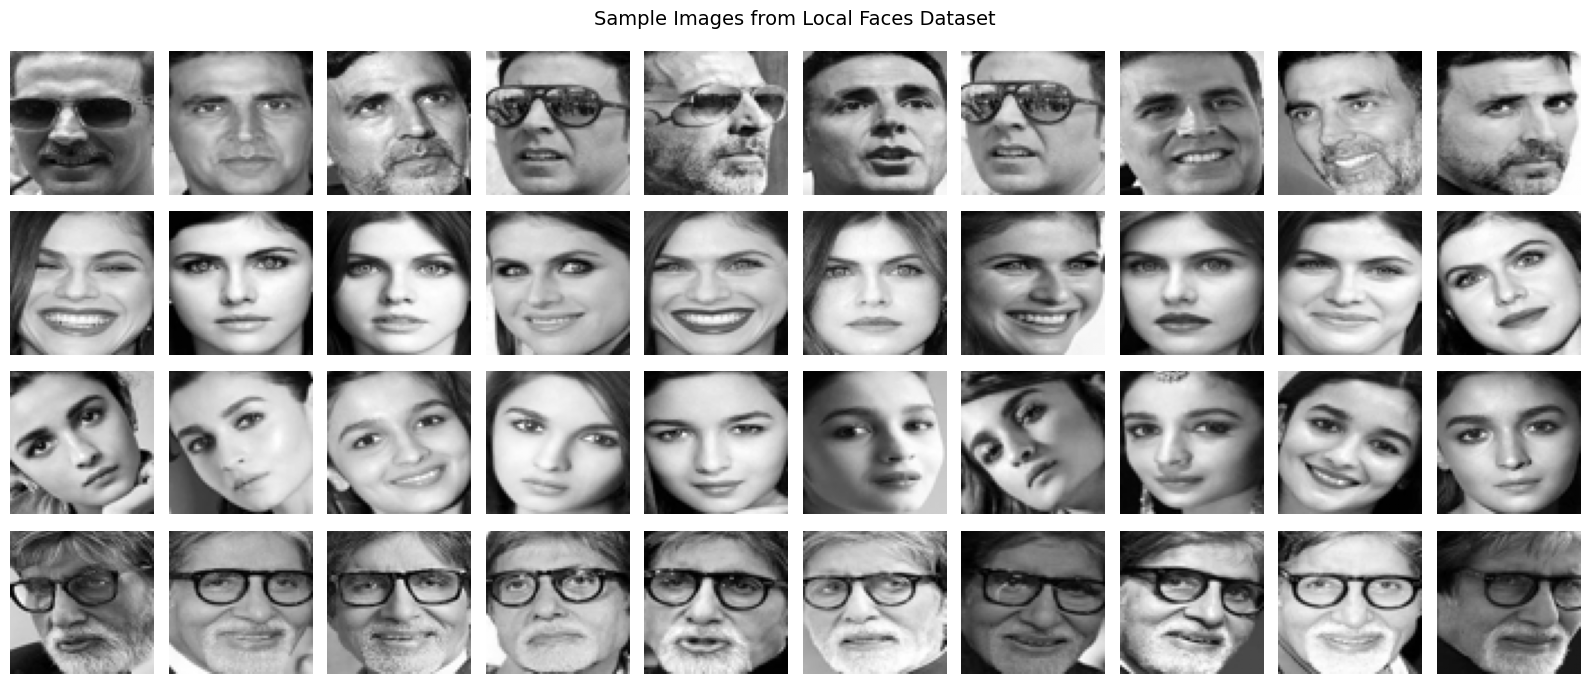

In [ ]:
rows, cols = 4, 10
fig, axes = plt.subplots(rows, cols, figsize=(16, 7), subplot_kw={'xticks': [], 'yticks': []})
fig.suptitle('Sample Images from Local Faces Dataset', fontsize=14)

selected_people = np.unique(y)[:rows]

for row, person_id in enumerate(selected_people):
    person_indices = np.where(y == person_id)[0][:cols]
    for col in range(cols):
        ax = axes[row, col]
        if col < len(person_indices):
            ax.imshow(images[person_indices[col]], cmap='gray')
        ax.axis('off')

    axes[row, 0].set_ylabel(class_names[person_id], fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
from scipy import ndimage
from skimage import exposure

def augment_image(img):
    augmented = []
    augmented.append(img)
    augmented.append(np.fliplr(img))
    augmented.append(ndimage.rotate(img, 5, reshape=False, mode='nearest'))
    augmented.append(ndimage.rotate(img, -5, reshape=False, mode='nearest'))
    img_eq = exposure.equalize_hist(img)
    augmented.append(img_eq)
    shifted = ndimage.shift(img, [2, 2], mode='nearest')
    augmented.append(shifted)
    return augmented

print("Applying data augmentation to training images...")
print("Original dataset size:", X.shape[0])

X_augmented = []
y_augmented = []

for i in range(len(X)):
    img_2d = images[i]
    augmented_imgs = augment_image(img_2d)
    for aug_img in augmented_imgs:
        X_augmented.append(aug_img.reshape(-1))
        y_augmented.append(y[i])

X_augmented = np.array(X_augmented, dtype=np.float32)
y_augmented = np.array(y_augmented, dtype=np.int64)

print(f"Augmented dataset size: {X_augmented.shape[0]}")
print(f"Augmentation factor: {X_augmented.shape[0] / X.shape[0]:.1f}x")
print(f"Features per image: {X_augmented.shape[1]}")

Applying data augmentation to training images...
Original dataset size: 1483
Augmented dataset size: 8898
Augmentation factor: 6.0x
Features per image: 4096


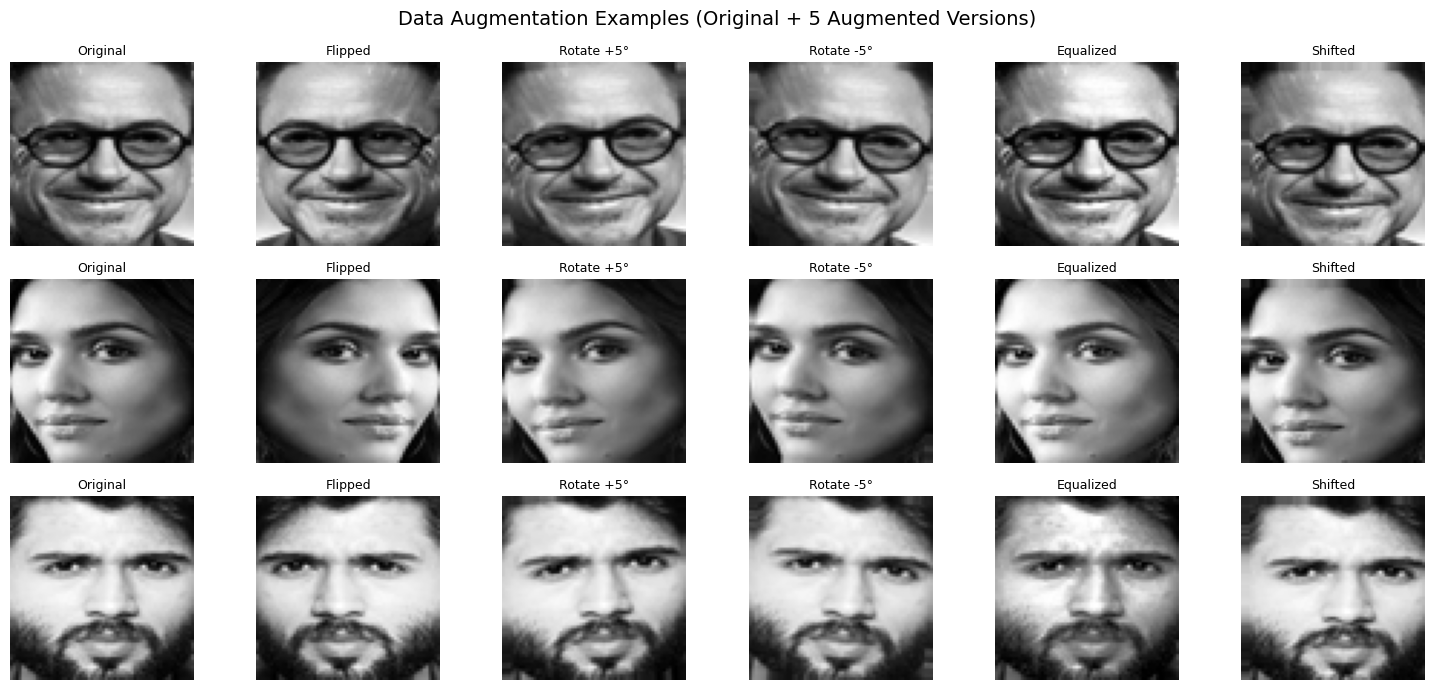


✓ Each training image generates 6 variations


In [ ]:
fig, axes = plt.subplots(3, 6, figsize=(15, 7))
fig.suptitle('Data Augmentation Examples (Original + 5 Augmented Versions)', fontsize=14)

sample_person = np.random.choice(np.unique(y), 3, replace=False)

for row, person_id in enumerate(sample_person):
    person_img_idx = np.where(y == person_id)[0][0]
    img_2d = images[person_img_idx]
    augmented_imgs = augment_image(img_2d)
    for col in range(6):
        ax = axes[row, col]
        ax.imshow(augmented_imgs[col], cmap='gray')
        if col == 0:
            ax.set_title('Original', fontsize=9)
            ax.set_ylabel(class_names[person_id], fontsize=10)
        else:
            titles = ['Flipped', 'Rotate +5°', 'Rotate -5°', 'Equalized', 'Shifted']
            ax.set_title(titles[col-1], fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\n✓ Each training image generates {len(augment_image(images[0]))} variations")

In [ ]:
indices_aug = np.arange(len(y_augmented))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_augmented, y_augmented, indices_aug, test_size=0.2, random_state=42, stratify=y_augmented
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# Feature scaling - normalize the data for better ANN performance
scaler = StandardScaler()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData preprocessing completed!")

Training samples: 7118
Testing samples: 1780

Data preprocessing completed!
Train/Test split: 7118/1780 = 4.0:1


In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(1024, 512, 256),
    activation='relu',
    solver='adam',
    max_iter=100,
    random_state=42,
    verbose=True,
    early_stopping=True,
    validation_fraction=0.1,
    learning_rate_init=0.001,
    learning_rate='adaptive',
    batch_size=32,
    alpha=0.0001
)

print("IMPROVED ANN Model Configuration:")
print("=" * 60)
print(f"  Architecture: 4096 → 1024 → 512 → 256 → {len(class_names)}")
print(f"  Hidden Layers: {mlp.hidden_layer_sizes}")
print(f"  Activation Function: {mlp.activation}")
print(f"  Optimizer: {mlp.solver}")
print(f"  Max Iterations: {mlp.max_iter}")
print(f"  Learning Rate: {mlp.learning_rate} (initial: {mlp.learning_rate_init})")
print(f"  Batch Size: {mlp.batch_size}")
print(f"  Early Stopping: {mlp.early_stopping}")
print(f"  Output Classes: {len(class_names)}")
print(f"  Regularization (alpha): {mlp.alpha}")
print("=" * 60)

IMPROVED ANN Model Configuration:
  Architecture: 4096 → 1024 → 512 → 256 → 31
  Hidden Layers: (1024, 512, 256)
  Activation Function: relu
  Optimizer: adam
  Max Iterations: 100
  Learning Rate: adaptive (initial: 0.001)
  Batch Size: 32
  Early Stopping: True
  Output Classes: 31
  Regularization (alpha): 0.0001


In [ ]:
print("Training the ANN model...")
print("=" * 60)
mlp.fit(X_train_scaled, y_train)
print("=" * 60)
print("\nTraining completed!")
print(f"Number of iterations: {mlp.n_iter_}")
print(f"Number of layers: {mlp.n_layers_}")
print(f"Final loss: {mlp.loss_:.6f}")

Training the ANN model...
Iteration 1, loss = 2.25928742
Validation score: 0.532303
Iteration 2, loss = 1.22977828
Validation score: 0.630618
Iteration 3, loss = 0.86789807
Validation score: 0.712079
Iteration 4, loss = 0.60952440
Validation score: 0.778090
Iteration 5, loss = 0.49964395
Validation score: 0.780899
Iteration 6, loss = 0.39474289
Validation score: 0.818820
Iteration 7, loss = 0.34198702
Validation score: 0.751404
Iteration 8, loss = 0.40516921
Validation score: 0.797753
Iteration 9, loss = 0.33719402
Validation score: 0.799157
Iteration 10, loss = 0.40466677
Validation score: 0.811798
Iteration 11, loss = 0.29095106
Validation score: 0.820225
Iteration 12, loss = 0.24758505
Validation score: 0.865169
Iteration 13, loss = 0.30840028
Validation score: 0.761236
Iteration 14, loss = 0.39554346
Validation score: 0.816011
Iteration 15, loss = 0.22906546
Validation score: 0.867978
Iteration 16, loss = 0.24062794
Validation score: 0.806180
Iteration 17, loss = 0.38383205
Validat

In [ ]:
y_train_pred = mlp.predict(X_train_scaled)
y_test_pred = mlp.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred) * 100
test_accuracy = accuracy_score(y_test, y_test_pred) * 100

print("Model Performance:")
print("=" * 60)
print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Testing Accuracy: {test_accuracy:.2f}%")
print("=" * 60)

Model Performance:
Training Accuracy: 94.48%
Testing Accuracy: 81.40%


In [ ]:
print("Classification Report (Test Set):")
print("=" * 60)
print(classification_report(y_test, y_test_pred))

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.76      0.85      0.80        59
           1       0.88      0.73      0.80        59
           2       0.57      0.85      0.68        59
           3       0.91      1.00      0.95        59
           4       0.84      0.64      0.73        59
           5       0.70      0.66      0.68        59
           6       0.88      0.83      0.85        59
           7       0.88      0.86      0.87        59
           8       0.87      0.78      0.82        58
           9       0.79      0.85      0.82        59
          10       0.88      0.76      0.82        59
          11       0.75      0.88      0.81        59
          12       0.86      0.86      0.86        58
          13       0.86      0.71      0.78        59
          14       0.76      0.98      0.86        59
          15       0.87      0.76      0.81        59
          16       0.72      0.88      0.79    

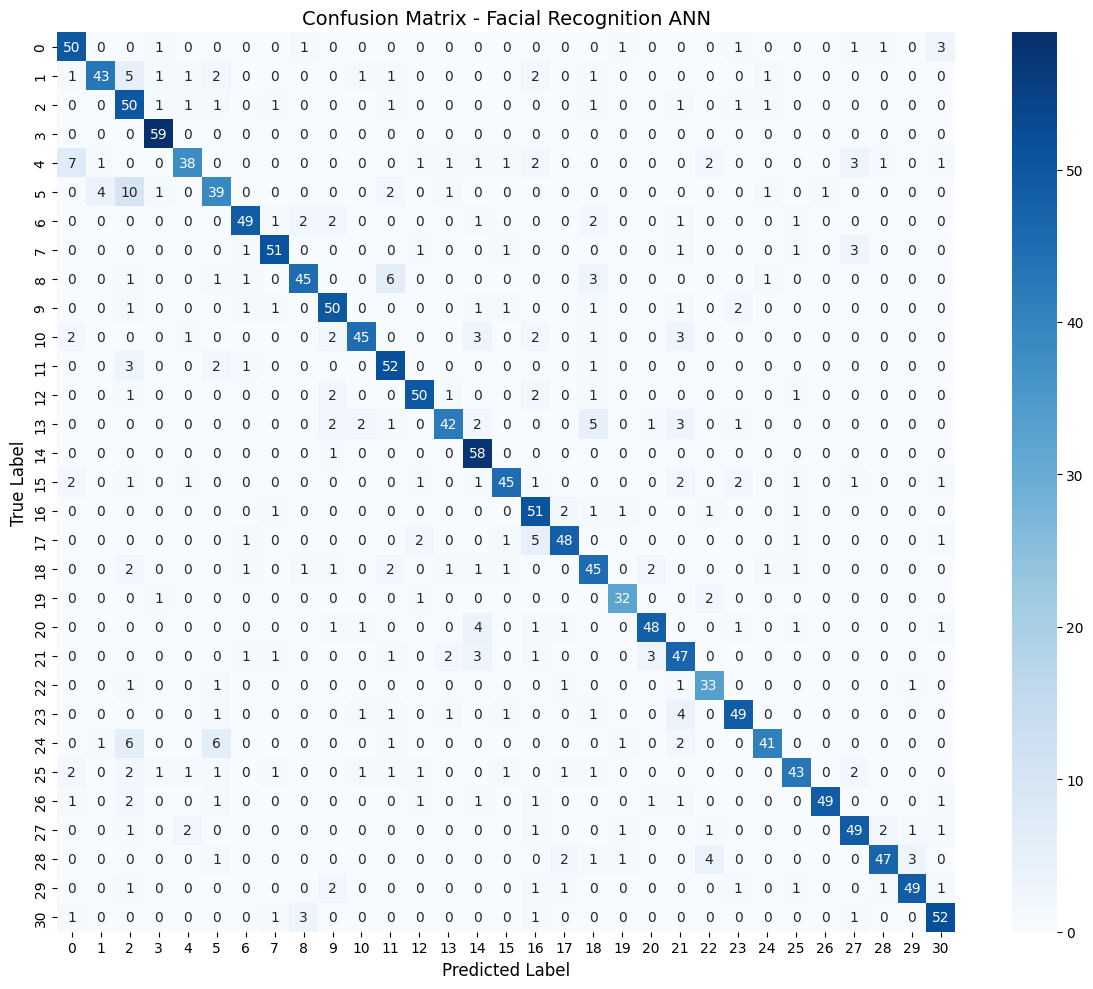

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix - Facial Recognition ANN', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

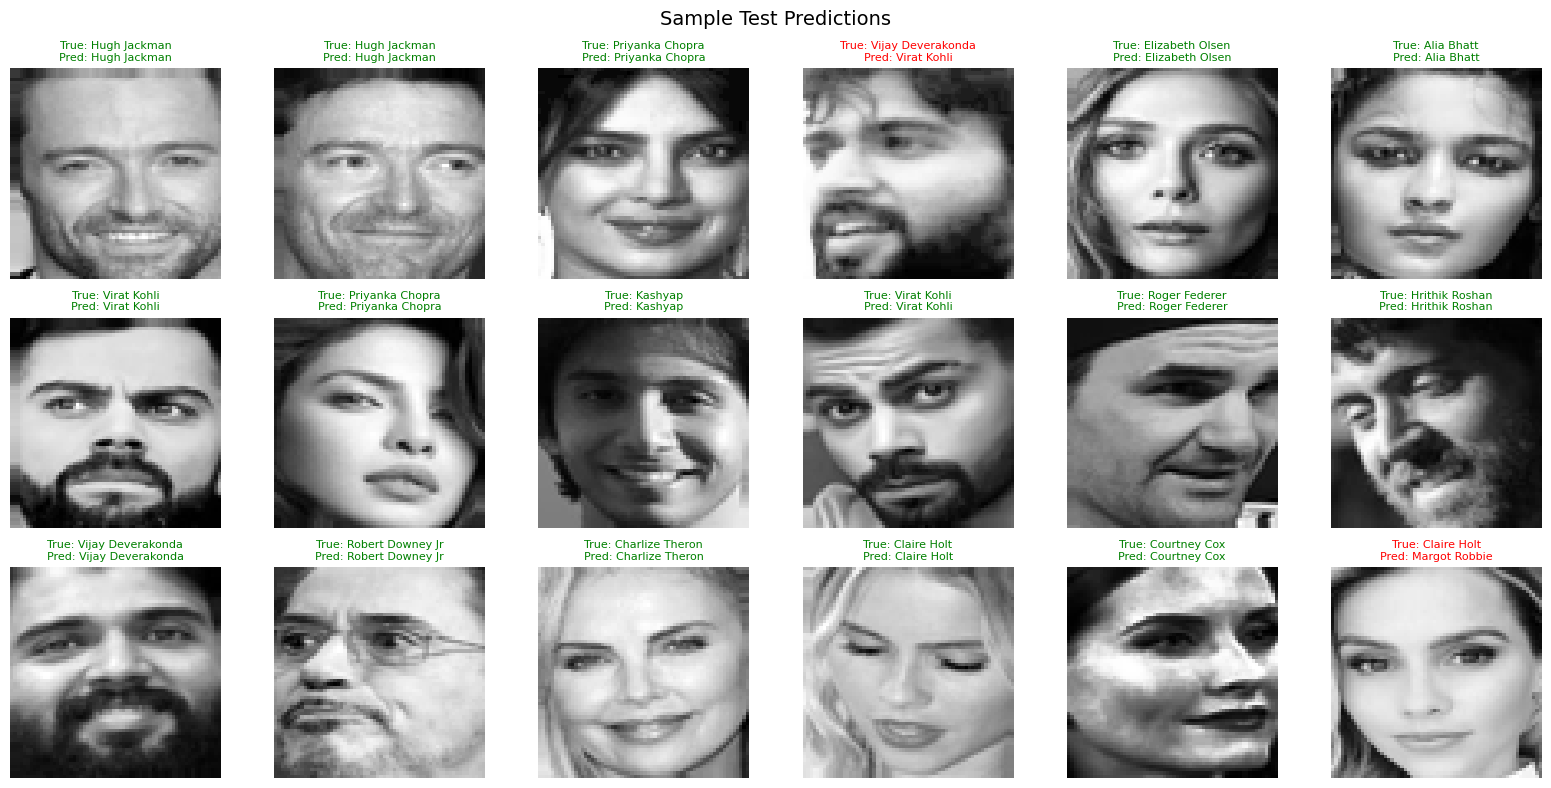

In [ ]:
fig, axes = plt.subplots(3, 6, figsize=(16, 8))
fig.suptitle('Sample Test Predictions', fontsize=14)

num_show = min(18, len(X_test))

for idx, ax in enumerate(axes.flat):
    if idx < num_show:
        ax.imshow(X_test[idx].reshape(64, 64), cmap='gray')

        true_label = int(y_test[idx])
        pred_label = int(y_test_pred[idx])
        color = 'green' if true_label == pred_label else 'red'

        ax.set_title(
            f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}',
            color=color,
            fontsize=8
        )
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

Number of misclassified samples: 331 out of 1780
Error rate: 18.60%


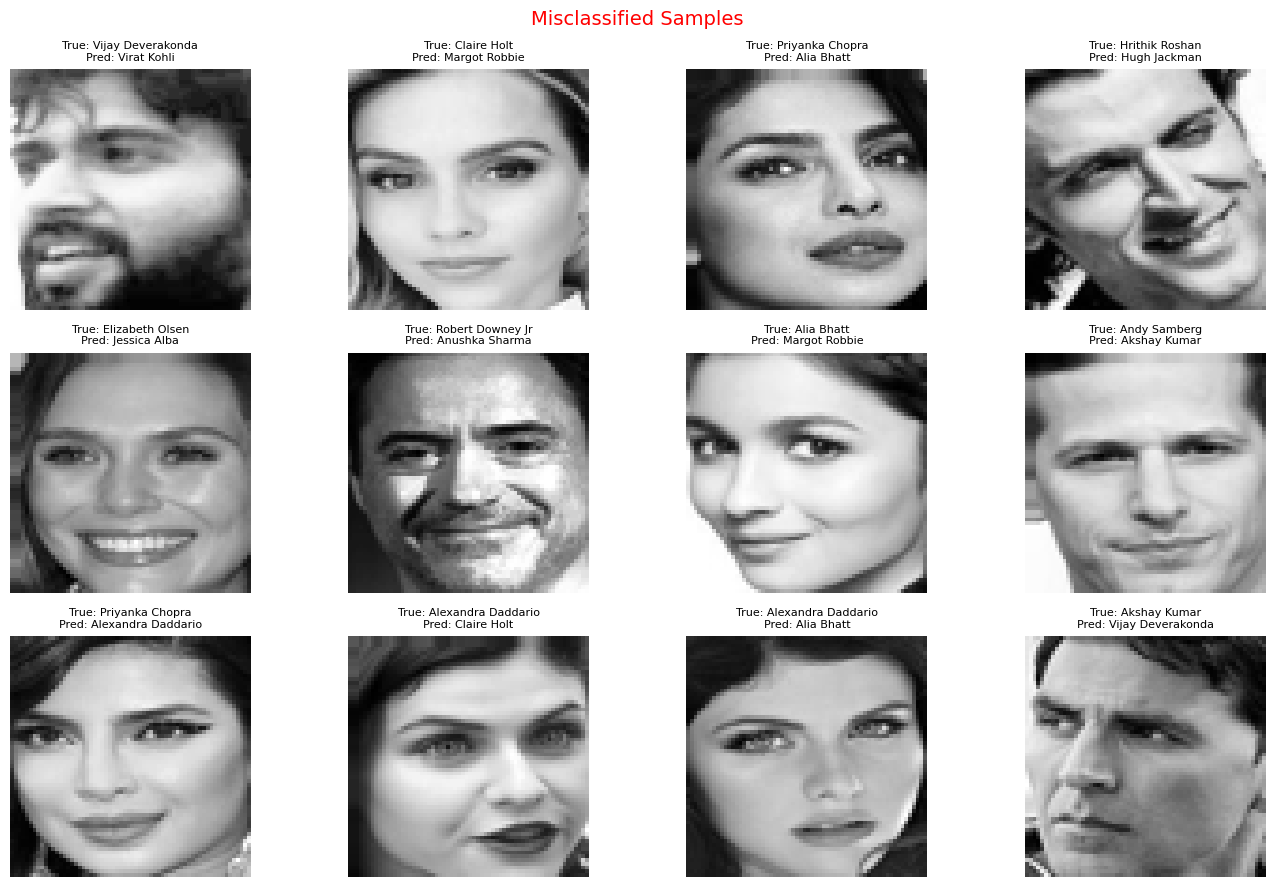

In [ ]:
misclassified_indices = np.where(y_test != y_test_pred)[0]
num_misclassified = len(misclassified_indices)

print(f"Number of misclassified samples: {num_misclassified} out of {len(y_test)}")
print(f"Error rate: {(num_misclassified/len(y_test)*100):.2f}%")

# Visualize some misclassified images (if any)
if num_misclassified > 0:
    num_to_show = min(12, num_misclassified)
    fig, axes = plt.subplots(3, 4, figsize=(14, 9))
    fig.suptitle('Misclassified Samples', fontsize=14, color='red')

    for idx, ax in enumerate(axes.flat):
        if idx < num_to_show:
            misc_idx = misclassified_indices[idx]
            img = X_test[misc_idx].reshape(64, 64)
            ax.imshow(img, cmap='gray')

            true_label = int(y_test[misc_idx])
            pred_label = int(y_test_pred[misc_idx])

            ax.set_title(
                f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}',
                fontsize=8
            )
            ax.axis('off')
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Perfect classification! No misclassified samples.")

In [ ]:
def recognize_face(image_data, display=True):
    if image_data.shape != (4096,):
        raise ValueError("Image must be flattened to 4096 features")

    image_scaled = scaler.transform(image_data.reshape(1, -1))

    prediction = int(mlp.predict(image_scaled)[0])
    confidence = mlp.predict_proba(image_scaled)[0]
    max_confidence = float(np.max(confidence) * 100)
    predicted_name = class_names[prediction]

    if display:
        plt.figure(figsize=(6, 6))
        plt.imshow(image_data.reshape(64, 64), cmap='gray')
        plt.title(
            f'Predicted: {predicted_name}\nConfidence: {max_confidence:.2f}%',
            fontsize=13
        )
        plt.axis('off')
        plt.show()

    return prediction, predicted_name, max_confidence

In [ ]:
import joblib

model_dir = Path(".")

joblib.dump(mlp, model_dir / "facial_recognition_model.pkl")
joblib.dump(scaler, model_dir / "scaler.pkl")
joblib.dump(class_names, model_dir / "class_names.pkl")

print("Model saved successfully!")
print(f"  - Model: {(model_dir / 'facial_recognition_model.pkl').resolve()}")
print(f"  - Scaler: {(model_dir / 'scaler.pkl').resolve()}")
print(f"  - Class Names: {(model_dir / 'class_names.pkl').resolve()}")
print("\nRun the web app with: streamlit run FacialRecognitionANN/app.py")

Model saved successfully!
  - Model: C:\CODING\PYTHON\ML\FacialRecognitionANN\facial_recognition_model.pkl
  - Scaler: C:\CODING\PYTHON\ML\FacialRecognitionANN\scaler.pkl
  - Class Names: C:\CODING\PYTHON\ML\FacialRecognitionANN\class_names.pkl

Run the web app with: streamlit run FacialRecognitionANN/app.py
